In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [4]:
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

print(f"Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()

Dataset loaded: 7043 rows, 21 columns


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
print("=== COLUMN TYPES ===")
print(df.dtypes)

print("\n=== MISSING VALUES ===")
missing = df.isnull().sum()
print(missing[missing > 0])

print("\n=== CHURN DISTRIBUTION ===")
print(df['Churn'].value_counts())
print(df['Churn'].value_counts(normalize=True).round(3) * 100)

=== COLUMN TYPES ===
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

=== MISSING VALUES ===
Series([], dtype: int64)

=== CHURN DISTRIBUTION ===
Churn
No     5174
Yes    1869
Name: count, dtype: int64
Churn
No     73.5
Yes    26.5
Name: proportion, dtype: float64


In [6]:
# Fix TotalCharges (string → float, fill blanks)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].fillna(0, inplace=True)

# Encode Churn (Yes→1, No→0)
df['Churn_Binary'] = (df['Churn'] == 'Yes').astype(int)

# Drop CustomerID (not needed for analysis)
df.drop(columns=['customerID'], inplace=True)

# Final check
print("=== CLEAN DATA SUMMARY ===")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
print("Missing values remaining:", df.isnull().sum().sum())

# Save cleaned file
df.to_csv('telco_churn_cleaned.csv', index=False)
print("Cleaned dataset saved!")

=== CLEAN DATA SUMMARY ===
Rows: 7043, Columns: 21
Missing values remaining: 0
Cleaned dataset saved!


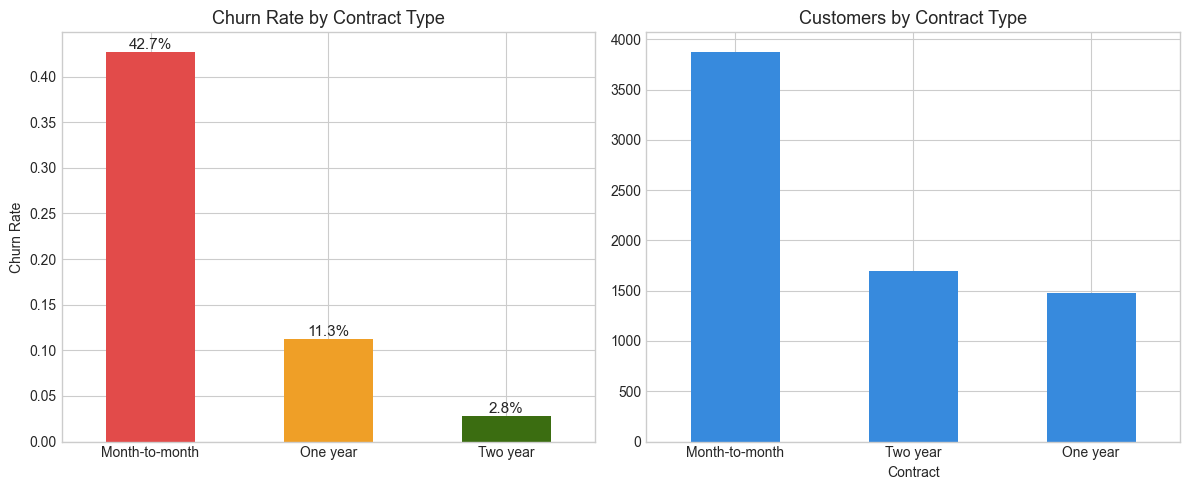

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left chart — churn rate by contract type
contract_churn = df.groupby('Contract')['Churn'].value_counts(normalize=True).unstack()
contract_churn['Yes'].sort_values(ascending=False).plot(
    kind='bar', ax=axes[0], color=['#E24B4A', '#EF9F27', '#3B6D11']
)
axes[0].set_title('Churn Rate by Contract Type', fontsize=13)
axes[0].set_ylabel('Churn Rate')
axes[0].set_xlabel('')
axes[0].tick_params(rotation=0)

for p in axes[0].patches:
    axes[0].annotate(f'{p.get_height():.1%}',
        (p.get_x() + p.get_width()/2., p.get_height()),
        ha='center', va='bottom', fontsize=11)

# Right chart — customer count by contract type
df['Contract'].value_counts().plot(kind='bar', ax=axes[1], color='#378ADD')
axes[1].set_title('Customers by Contract Type', fontsize=13)
axes[1].tick_params(rotation=0)

plt.tight_layout()
plt.savefig('chart1_contract_churn.png', dpi=150, bbox_inches='tight')
plt.show()

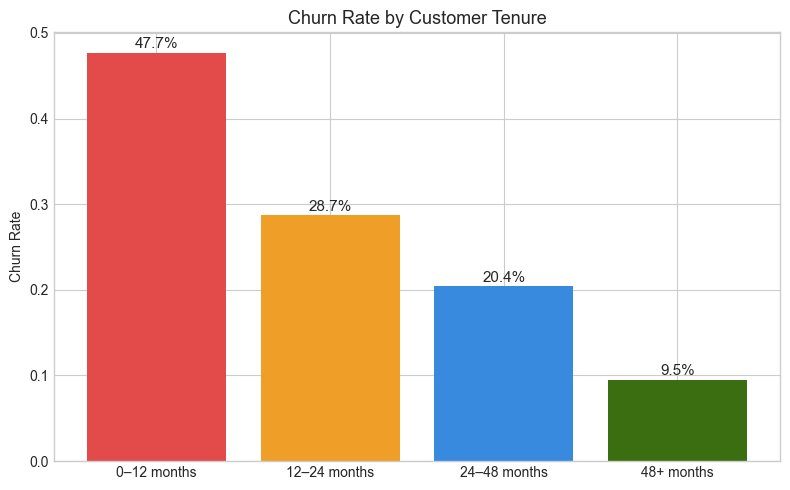

In [8]:
# Churn rate by tenure (how long they've been a customer)
df['tenure_group'] = pd.cut(df['tenure'],
    bins=[0, 12, 24, 48, 72],
    labels=['0–12 months', '12–24 months', '24–48 months', '48+ months'])

tenure_churn = df.groupby('tenure_group', observed=True)['Churn_Binary'].mean()

plt.figure(figsize=(8, 5))
bars = plt.bar(tenure_churn.index, tenure_churn.values,
               color=['#E24B4A', '#EF9F27', '#378ADD', '#3B6D11'])
plt.title('Churn Rate by Customer Tenure', fontsize=13)
plt.ylabel('Churn Rate')

for bar, val in zip(bars, tenure_churn.values):
    plt.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.005,
             f'{val:.1%}', ha='center', fontsize=11)

plt.tight_layout()
plt.savefig('chart2_tenure_churn.png', dpi=150, bbox_inches='tight')
plt.show()

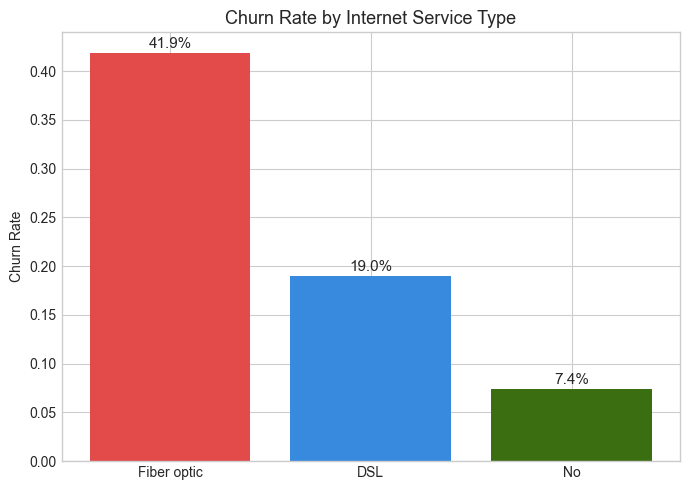

In [9]:
# Churn rate by internet service type
internet_churn = df.groupby('InternetService')['Churn_Binary'].mean().sort_values(ascending=False)

plt.figure(figsize=(7, 5))
colors = ['#E24B4A' if v > 0.3 else '#378ADD' if v > 0.1 else '#3B6D11' for v in internet_churn.values]
bars = plt.bar(internet_churn.index, internet_churn.values, color=colors)
plt.title('Churn Rate by Internet Service Type', fontsize=13)
plt.ylabel('Churn Rate')

for bar, val in zip(bars, internet_churn.values):
    plt.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.005,
             f'{val:.1%}', ha='center', fontsize=11)

plt.tight_layout()
plt.savefig('chart3_internet_churn.png', dpi=150, bbox_inches='tight')
plt.show()

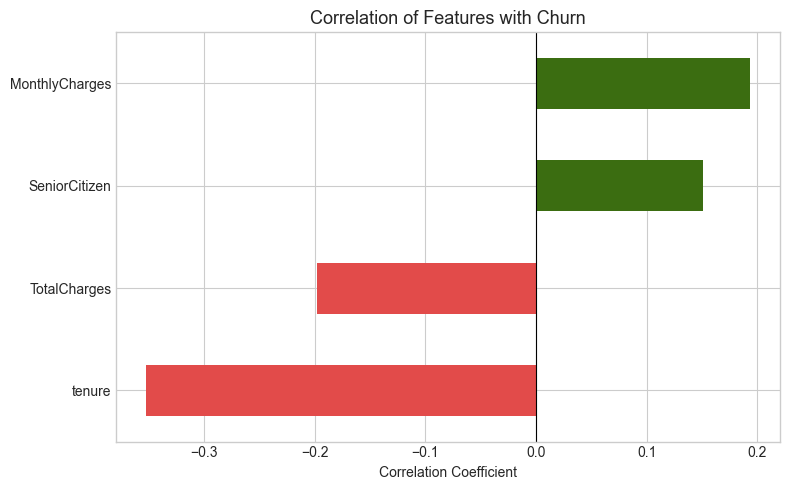

In [10]:
# Correlation of numeric features with churn
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr_with_churn = df[numeric_cols].corr()['Churn_Binary'].drop('Churn_Binary').sort_values()

plt.figure(figsize=(8, 5))
colors = ['#E24B4A' if v < 0 else '#3B6D11' for v in corr_with_churn.values]
corr_with_churn.plot(kind='barh', color=colors)
plt.title('Correlation of Features with Churn', fontsize=13)
plt.xlabel('Correlation Coefficient')
plt.axvline(x=0, color='black', linewidth=0.8)
plt.tight_layout()
plt.savefig('chart4_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

In [11]:
# Create risk segments using business rules from EDA
def assign_risk_segment(row):
    if row['Contract'] == 'Month-to-month' and row['tenure'] < 12:
        return 'High Risk'
    elif row['Contract'] == 'Month-to-month' or row['tenure'] < 24:
        return 'Medium Risk'
    else:
        return 'Low Risk'

df['Risk_Segment'] = df.apply(assign_risk_segment, axis=1)

# Validate segments
segment_analysis = df.groupby('Risk_Segment').agg(
    Customer_Count=('Churn_Binary', 'count'),
    Churn_Rate=('Churn_Binary', 'mean'),
    Churned_Customers=('Churn_Binary', 'sum'),
    Avg_Monthly_Charges=('MonthlyCharges', 'mean')
).round(3)

segment_analysis['Churn_Rate'] = segment_analysis['Churn_Rate'].map('{:.1%}'.format)
segment_analysis['Avg_Monthly_Charges'] = segment_analysis['Avg_Monthly_Charges'].map('${:.2f}'.format)
print(segment_analysis)

# Save final EDA dataset
df.to_csv('telco_churn_eda_complete.csv', index=False)
print("\nPhase 2 complete! Ready for modelling.")

              Customer_Count Churn_Rate  Churned_Customers Avg_Monthly_Charges
Risk_Segment                                                                  
High Risk               1908      51.9%                991              $58.02
Low Risk                2725       6.8%                185              $66.78
Medium Risk             2410      28.8%                693              $67.81

Phase 2 complete! Ready for modelling.


In [12]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Modelling libraries loaded!")

Modelling libraries loaded!


In [13]:
# Encode all categorical columns into numbers
df_model = pd.get_dummies(df, drop_first=True)

# Remove the original Churn text column (we use Churn_Binary instead)
df_model.drop(columns=['Churn_Yes'], inplace=True, errors='ignore')

# Separate features (X) and target (y)
X = df_model.drop(columns=['Churn_Binary', 'Risk_Segment_Medium Risk', 
                             'Risk_Segment_Low Risk'], errors='ignore')
y = df_model['Churn_Binary']

print(f"Features: {X.shape[1]} columns")
print(f"Target: {y.shape[0]} rows")
print(f"Churn rate in target: {y.mean():.1%}")

Features: 33 columns
Target: 7043 rows
Churn rate in target: 26.5%


In [14]:
# Split data — 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale the numeric features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set: {X_train.shape[0]} customers")
print(f"Testing set: {X_test.shape[0]} customers")
print("Data is ready for modelling!")

Training set: 5634 customers
Testing set: 1409 customers
Data is ready for modelling!


In [15]:
# Build and train the logistic regression model
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)

# Make predictions on test set
y_pred = model.predict(X_test_scaled)

# Check accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.1%}")
print("\n=== DETAILED PERFORMANCE ===")
print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))

Model Accuracy: 81.5%

=== DETAILED PERFORMANCE ===
              precision    recall  f1-score   support

    No Churn       0.85      0.91      0.88      1036
       Churn       0.68      0.56      0.62       373

    accuracy                           0.81      1409
   macro avg       0.77      0.73      0.75      1409
weighted avg       0.81      0.81      0.81      1409



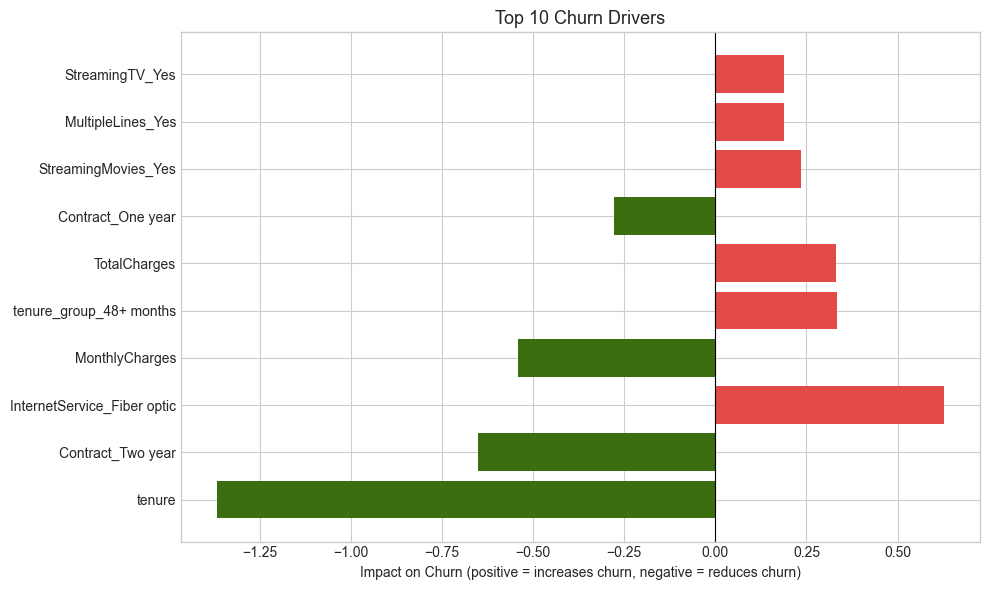


Top 5 churn drivers:
                        Feature  Coefficient
1                        tenure    -1.366333
25            Contract_Two year    -0.651472
10  InternetService_Fiber optic     0.626656
2                MonthlyCharges    -0.540982
32      tenure_group_48+ months     0.333234


In [16]:
# Extract top churn drivers from model
import pandas as pd

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
})

# Sort by absolute importance
feature_importance['Abs_Coefficient'] = feature_importance['Coefficient'].abs()
feature_importance = feature_importance.sort_values('Abs_Coefficient', ascending=False).head(10)

# Plot
plt.figure(figsize=(10, 6))
colors = ['#E24B4A' if x > 0 else '#3B6D11' for x in feature_importance['Coefficient']]
plt.barh(feature_importance['Feature'], feature_importance['Coefficient'], color=colors)
plt.title('Top 10 Churn Drivers', fontsize=13)
plt.xlabel('Impact on Churn (positive = increases churn, negative = reduces churn)')
plt.axvline(x=0, color='black', linewidth=0.8)
plt.tight_layout()
plt.savefig('chart5_churn_drivers.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nTop 5 churn drivers:")
print(feature_importance[['Feature', 'Coefficient']].head())

In [17]:
# Get churn probability for every customer
y_prob = model.predict_proba(X_test_scaled)[:, 1]

# Build output dataframe
results = pd.DataFrame({
    'Churn_Probability': y_prob,
    'Predicted_Churn': y_pred,
    'Actual_Churn': y_test.values
})

# Assign risk labels
results['Risk_Level'] = pd.cut(y_prob,
    bins=[0, 0.3, 0.7, 1.0],
    labels=['Low Risk', 'Medium Risk', 'High Risk'])

# Summary
print("=== RISK SEGMENT SUMMARY ===")
print(results['Risk_Level'].value_counts())
print(f"\nHigh risk customers identified: {(results['Risk_Level'] == 'High Risk').sum()}")
print(f"Estimated annual revenue at risk: ${(results['Risk_Level'] == 'High Risk').sum() * 240:,}")

# Save for Tableau
results.to_csv('churn_predictions.csv', index=False)
print("\nPredictions saved! Ready for Tableau dashboard.")

=== RISK SEGMENT SUMMARY ===
Risk_Level
Low Risk       863
Medium Risk    431
High Risk      115
Name: count, dtype: int64

High risk customers identified: 115
Estimated annual revenue at risk: $27,600

Predictions saved! Ready for Tableau dashboard.


In [18]:
# Build complete dashboard dataset
df_dashboard = df.copy()

# Add model predictions to full dataset
# First re-run predictions on ALL data (not just test set)
X_full = df_model.drop(columns=['Churn_Binary', 'Risk_Segment_Medium Risk',
                                  'Risk_Segment_Low Risk'], errors='ignore')
X_full_scaled = scaler.transform(X_full)
df_dashboard['Churn_Probability'] = model.predict_proba(X_full_scaled)[:, 1]
df_dashboard['Predicted_Churn'] = model.predict(X_full_scaled)

# Add risk level
df_dashboard['Risk_Level'] = pd.cut(df_dashboard['Churn_Probability'],
    bins=[0, 0.3, 0.7, 1.0],
    labels=['Low Risk', 'Medium Risk', 'High Risk'])

# Add revenue at risk column
df_dashboard['Revenue_At_Risk'] = df_dashboard['Churn_Probability'] * 240

# Final summary
print("=== DASHBOARD DATASET READY ===")
print(f"Total customers: {len(df_dashboard)}")
print(f"\nRisk breakdown:")
print(df_dashboard['Risk_Level'].value_counts())
print(f"\nTotal revenue at risk: ${df_dashboard['Revenue_At_Risk'].sum():,.0f}")

# Save for Tableau
df_dashboard.to_csv('dashboard_data.csv', index=False)
print("\ndashboard_data.csv saved! Ready for Tableau.")

=== DASHBOARD DATASET READY ===
Total customers: 7043

Risk breakdown:
Risk_Level
Low Risk       4372
Medium Risk    2132
High Risk       539
Name: count, dtype: int64

Total revenue at risk: $450,251

dashboard_data.csv saved! Ready for Tableau.
